<a href="https://colab.research.google.com/github/tibyishaka/Formative_ML_technique_1/blob/main/Milan_Traffic_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milan Mobile Network Traffic Forecasting Notebook

This notebook is the **experiment pipeline** for the formative assignment of *"Comparative Analysis of Sequential Models
for Mobile Network Traffic Forecasting."* It downloads and processes the Milan telecom dataset, runs the
exploratory analysis, tunes and trains three forecasting models, and evaluates them - saving every
figure to `./figures/` in teh google drive folder and every numeric result to `./results/` there also.


## 1. Setup

In [ ]:
!pip install -q statsmodels tqdm pyarrow

import os, io, json, time, platform, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import statsmodels.api as sm

np.random.seed(42)
tf.random.set_seed(42)

try:
    IN_COLAB = "google.colab" in str(get_ipython())
except NameError:
    IN_COLAB = False
print("Running in Colab:", IN_COLAB)
print("TensorFlow:", tf.__version__, "| GPU devices:", tf.config.list_physical_devices("GPU"))

Running in Colab: True
TensorFlow: 2.20.0 | GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Optional: mount Google Drive so everything EXCEPT the raw dataset persists across Colab sessions --
# the small (a few MB total) processed cache, figures, and result tables all live in their own folders
# under one Drive base folder. The raw 19 GB dataset stays on the local Colab disk only: there is no
# reason to sync 19 GB of raw text into Drive, and it would eat into your Drive quota for no benefit
# (it downloads fresh each session in a couple minutes anyway once the guestbook/signed-URL flow runs).
USE_DRIVE = True

if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_BASE_DIR = "/content/drive/MyDrive/ML_technique_1"
    CACHE_DIR = os.path.join(DRIVE_BASE_DIR, "cache")
    FIGURES_DIR = os.path.join(DRIVE_BASE_DIR, "figures")
    RESULTS_DIR = os.path.join(DRIVE_BASE_DIR, "results")
else:
    CACHE_DIR = "./milan_traffic_cache"
    FIGURES_DIR = "./figures"
    RESULTS_DIR = "./results"

RAW_DATA_DIR = "/content/milan_raw_data" if IN_COLAB else "./milan_raw_data"

for d in (CACHE_DIR, RAW_DATA_DIR, FIGURES_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)
print("Cache dir:", CACHE_DIR)
print("Raw data dir (local only, not synced to Drive):", RAW_DATA_DIR)
print("Figures dir:", FIGURES_DIR)
print("Results dir:", RESULTS_DIR)

def save_json(obj, name):
    path = os.path.join(RESULTS_DIR, name)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    print("Saved:", path)

def save_fig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

## 2. Data Download

Raw format: `sms-call-internet-mi-YYYY-MM-DD.txt`, tab-separated, no header, one row per
`(square_id, time_interval, country_code)`:
`square_id, time_interval (ms epoch, UTC), country_code, sms_in, sms_out, call_in, call_out, internet`.

Verified against the sample file: a `(square_id, time_interval)` pair's total activity is the **sum
across country rows** (missing country rows = 0 contribution). `time_interval` is UTC; Milan is
`Europe/Rome` (UTC+1, no DST change in Nov-Dec), so `2013-11-01`'s file starts at `2013-10-31 23:00 UTC`
= `2013-11-01 00:00` local - all date-based logic below converts to `Europe/Rome` first.

File IDs below were resolved once via the Harvard Dataverse API (`doi:10.7910/DVN/EGZHFV`).

In [ ]:
FILE_IDS = {
    "2013-11-01": 2674255,
    "2013-11-02": 2674265,
    "2013-11-03": 2674273,
    "2013-11-04": 2674282,
    "2013-11-05": 2674279,
    "2013-11-06": 2674283,
    "2013-11-07": 2674271,
    "2013-11-08": 2674261,
    "2013-11-09": 2674268,
    "2013-11-10": 2674259,
    "2013-11-11": 2674272,
    "2013-11-12": 2674284,
    "2013-11-13": 2674257,
    "2013-11-14": 2674267,
    "2013-11-15": 2674281,
    "2013-11-16": 2674256,
    "2013-11-17": 2674266,
    "2013-11-18": 2674260,
    "2013-11-19": 2674280,
    "2013-11-20": 2674263,
    "2013-11-21": 2674276,
    "2013-11-22": 2674269,
    "2013-11-23": 2674277,
    "2013-11-24": 2674258,
    "2013-11-25": 2674262,
    "2013-11-26": 2674270,
    "2013-11-27": 2674274,
    "2013-11-28": 2674278,
    "2013-11-29": 2674264,
    "2013-11-30": 2674275,
    "2013-12-01": 2674292,
    "2013-12-02": 2674287,
    "2013-12-03": 2674294,
    "2013-12-04": 2674307,
    "2013-12-05": 2674291,
    "2013-12-06": 2674295,
    "2013-12-07": 2674301,
    "2013-12-08": 2674311,
    "2013-12-09": 2674313,
    "2013-12-10": 2674309,
    "2013-12-11": 2674314,
    "2013-12-12": 2674310,
    "2013-12-13": 2674315,
    "2013-12-14": 2674293,
    "2013-12-15": 2674306,
    "2013-12-16": 2674289,
    "2013-12-17": 2674316,
    "2013-12-18": 2674312,
    "2013-12-19": 2674286,
    "2013-12-20": 2674288,
    "2013-12-21": 2674303,
    "2013-12-22": 2674308,
    "2013-12-23": 2674290,
    "2013-12-24": 2674305,
    "2013-12-25": 2674304,
    "2013-12-26": 2674298,
    "2013-12-27": 2674297,
    "2013-12-28": 2674296,
    "2013-12-29": 2674317,
    "2013-12-30": 2674299,
    "2013-12-31": 2674302,
}
print(len(FILE_IDS), 'daily files (Nov 1 - Dec 31, 2013)')

61 daily files (Nov 1 - Dec 31, 2013)


In [ ]:
DATAVERSE_BASE = "https://dataverse.harvard.edu/api/access/datafile/"
COLUMN_NAMES = ["square_id", "time_interval", "country_code", "sms_in", "sms_out", "call_in", "call_out", "internet"]
# Harvard Dataverse's WAF challenges requests with no/default User-Agent (e.g. python-requests' default),
# returning a 4xx instead of the file -- a real browser-like header avoids this.
HTTP_HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"}
# This dataset also requires a Guestbook (Harvard Dataverse's download-tracking form) response before any
# file can be fetched -- a plain GET returns 400 "You may not download this file without the required
# Guestbook response". We satisfy it via the documented signed-URL flow: POST the guestbook response
# (this dataset's guestbook only requires an email), get back a short-lived signed URL, then GET that.
GUESTBOOK_EMAIL = "t.ibyishaka@alustudent.com"

def local_path(date_str):
    return os.path.join(RAW_DATA_DIR, f"sms-call-internet-mi-{date_str}.txt")

def get_signed_url(file_id):
    r = requests.post(
        f"{DATAVERSE_BASE}{file_id}?signed=true",
        json={"guestbookResponse": {"email": GUESTBOOK_EMAIL}},
        headers={**HTTP_HEADERS, "Content-Type": "application/json"},
        timeout=30,
    )
    r.raise_for_status()
    return r.json()["data"]["signedUrl"]

def download_one(date_str, file_id, chunk_bytes=1 << 20, min_expected_bytes=50_000_000):
    dest = local_path(date_str)
    if os.path.exists(dest) and os.path.getsize(dest) > min_expected_bytes:
        return date_str, "cached"
    signed_url = get_signed_url(file_id)
    with requests.get(signed_url, stream=True, timeout=180, headers=HTTP_HEADERS) as r:
        r.raise_for_status()
        tmp = dest + ".part"
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_bytes):
                if chunk:
                    f.write(chunk)
        os.replace(tmp, dest)
    return date_str, "downloaded"

def download_all(file_ids, max_workers=4):
    """Downloads all daily files to RAW_DATA_DIR, in parallel, skipping files already cached on disk.
    ~19 GB total; with 4 parallel connections this is the dominant cost of a first run."""
    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(download_one, d, fid): d for d, fid in file_ids.items()}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Downloading daily files"):
            results.append(fut.result())
    n_dl = sum(1 for _, s in results if s == "downloaded")
    n_cache = sum(1 for _, s in results if s == "cached")
    print(f"Downloaded {n_dl} new files, {n_cache} already cached.")
    return results

# NOTE: this downloads ~19 GB and can take 30-90 minutes depending on Colab's network throughput.
download_all(FILE_IDS, max_workers=4)

Downloaded 0 new files, 61 already cached.


[('2013-12-09', 'cached'),
 ('2013-12-14', 'cached'),
 ('2013-12-03', 'cached'),
 ('2013-11-26', 'cached'),
 ('2013-11-25', 'cached'),
 ('2013-11-21', 'cached'),
 ('2013-12-22', 'cached'),
 ('2013-12-20', 'cached'),
 ('2013-12-05', 'cached'),
 ('2013-11-27', 'cached'),
 ('2013-11-22', 'cached'),
 ('2013-11-15', 'cached'),
 ('2013-12-12', 'cached'),
 ('2013-12-31', 'cached'),
 ('2013-12-01', 'cached'),
 ('2013-11-28', 'cached'),
 ('2013-11-14', 'cached'),
 ('2013-11-05', 'cached'),
 ('2013-12-21', 'cached'),
 ('2013-11-07', 'cached'),
 ('2013-12-26', 'cached'),
 ('2013-12-25', 'cached'),
 ('2013-12-16', 'cached'),
 ('2013-11-09', 'cached'),
 ('2013-11-06', 'cached'),
 ('2013-12-28', 'cached'),
 ('2013-12-27', 'cached'),
 ('2013-12-24', 'cached'),
 ('2013-12-07', 'cached'),
 ('2013-11-16', 'cached'),
 ('2013-11-11', 'cached'),
 ('2013-12-19', 'cached'),
 ('2013-12-06', 'cached'),
 ('2013-11-04', 'cached'),
 ('2013-12-02', 'cached'),
 ('2013-11-03', 'cached'),
 ('2013-11-01', 'cached'),
 

## 3. Memory-Management Evidence

Measures naive (default dtypes, all 8 columns, single `pd.read_csv`) vs. optimized (2 columns,
downcast dtypes, chunked+incrementally aggregated) memory footprint on one real file. Exported to
`results/memory_management_evidence.json` to be included within the report of the assignment.

In [ ]:
sample_path = local_path("2013-11-01")

t0 = time.time()
naive = pd.read_csv(sample_path, sep="\t", header=None, names=COLUMN_NAMES)
t_naive = time.time() - t0
naive_mem_mb = naive.memory_usage(deep=True).sum() / 1e6
naive_rows = len(naive)
del naive

t0 = time.time()
peak_chunk_mem = 0
running_total = pd.Series(dtype="float64")
for chunk in pd.read_csv(sample_path, sep="\t", header=None, names=COLUMN_NAMES,
                          usecols=["square_id", "internet"],
                          dtype={"square_id": "uint16", "internet": "float32"},
                          chunksize=1_000_000):
    peak_chunk_mem = max(peak_chunk_mem, chunk.memory_usage(deep=True).sum())
    running_total = running_total.add(chunk.groupby("square_id")["internet"].sum(), fill_value=0)
t_opt = time.time() - t0
opt_final_mem_mb = running_total.memory_usage(deep=True) / 1e6
on_disk_mb = os.path.getsize(sample_path) / 1e6

memory_evidence = {
    "on_disk_mb_per_file": on_disk_mb,
    "rows_per_file": naive_rows,
    "naive_load_mem_mb": naive_mem_mb,
    "naive_load_time_s": t_naive,
    "streaming_peak_chunk_mem_mb": peak_chunk_mem / 1e6,
    "streaming_load_time_s": t_opt,
    "streaming_final_accumulator_mem_mb": opt_final_mem_mb,
    "peak_memory_reduction_factor": naive_mem_mb / (peak_chunk_mem / 1e6),
    "naive_extrapolated_61_files_gb": naive_mem_mb * 61 / 1000,
    "streaming_extrapolated_61_files_mb_peak": peak_chunk_mem / 1e6,
}
save_json(memory_evidence, "memory_management_evidence.json")
print(json.dumps(memory_evidence, indent=2))

Saved: /content/drive/MyDrive/ML_technique_1/results/memory_management_evidence.json
{
  "on_disk_mb_per_file": 322.874887,
  "rows_per_file": 4842625,
  "naive_load_mem_mb": 309.928132,
  "naive_load_time_s": 6.109772682189941,
  "streaming_peak_chunk_mem_mb": 6.000132,
  "streaming_load_time_s": 8.505136489868164,
  "streaming_final_accumulator_mem_mb": 0.1,
  "peak_memory_reduction_factor": 51.65355228851632,
  "naive_extrapolated_61_files_gb": 18.905616052000003,
  "streaming_extrapolated_61_files_mb_peak": 6.000132
}


## 4. Streaming Pipeline: Ranking + Area Extraction

Two bounded-memory passes over the cached local files (no re-downloading):
- **Pass A** - total Internet traffic per `square_id` over the full 2 months, all 10,000 cells (2 cols).
- **Pass B** - full-resolution time series for only the cells of interest (top-3 by Pass A, plus the two
  fixed squares 4159/4556), filtered per-chunk before concatenation.

In [ ]:
def stream_rank_totals(file_ids, force=False):
    cache_path = os.path.join(CACHE_DIR, "square_totals_2months.parquet")
    if os.path.exists(cache_path) and not force:
        print("Loaded cached ranking totals:", cache_path)
        return pd.read_parquet(cache_path)["internet_total"]

    totals = pd.Series(0.0, index=pd.RangeIndex(1, 10001), dtype="float64")
    for date_str in tqdm(sorted(file_ids), desc="Pass A: ranking totals"):
        path = local_path(date_str)
        for chunk in pd.read_csv(path, sep="\t", header=None, names=COLUMN_NAMES,
                                  usecols=["square_id", "internet"],
                                  dtype={"square_id": "uint16", "internet": "float32"},
                                  chunksize=1_000_000):
            g = chunk.groupby("square_id")["internet"].sum()
            totals = totals.add(g, fill_value=0)
    totals = totals.rename("internet_total").astype("float32")
    totals.to_frame().to_parquet(cache_path)
    print("Cached ranking totals to:", cache_path)
    return totals

square_totals = stream_rank_totals(FILE_IDS)
print(square_totals.describe())

Pass A: ranking totals:   0%|          | 0/61 [00:00<?, ?it/s]

Cached ranking totals to: /content/drive/MyDrive/ML_technique_1/cache/square_totals_2months.parquet
count    1.000000e+04
mean     5.499728e+05
std      8.862119e+05
min      2.136265e+02
25%      1.169186e+05
50%      2.747062e+05
75%      5.718442e+05
max      1.268267e+07
Name: internet_total, dtype: float64


In [ ]:
top3_ids = square_totals.sort_values(ascending=False).head(3).index.tolist()
print("Top-3 highest-traffic squares (2-month total):", top3_ids)

FIXED_SQUARES = [4159, 4556]
AREAS_OF_INTEREST = sorted(set(top3_ids) | set(FIXED_SQUARES))
print("All areas we need full-resolution series for:", AREAS_OF_INTEREST)

pd.DataFrame({"square_id": top3_ids, "rank": [1, 2, 3],
              "total_internet_traffic": square_totals.loc[top3_ids].values}
             ).to_csv(os.path.join(RESULTS_DIR, "top3_areas.csv"), index=False)

Top-3 highest-traffic squares (2-month total): [5161, 5059, 5259]
All areas we need full-resolution series for: [4159, 4556, 5059, 5161, 5259]


In [ ]:
def stream_area_series(file_ids, area_ids, force=False):
    cache_path = os.path.join(CACHE_DIR, "area_series_full_res.parquet")
    if os.path.exists(cache_path) and not force:
        print("Loaded cached area series:", cache_path)
        return pd.read_parquet(cache_path)

    area_set = set(area_ids)
    rows = []
    for date_str in tqdm(sorted(file_ids), desc="Pass B: extracting area series"):
        path = local_path(date_str)
        for chunk in pd.read_csv(path, sep="\t", header=None, names=COLUMN_NAMES,
                                  usecols=["square_id", "time_interval", "internet"],
                                  dtype={"square_id": "uint16", "time_interval": "int64", "internet": "float32"},
                                  chunksize=1_000_000):
            sub = chunk[chunk["square_id"].isin(area_set)]
            if len(sub) == 0:
                continue
            g = sub.groupby(["square_id", "time_interval"], as_index=False)["internet"].sum()
            rows.append(g)
    long_df = pd.concat(rows, ignore_index=True)
    long_df["ts_utc"] = pd.to_datetime(long_df["time_interval"], unit="ms", utc=True)
    long_df["ts_local"] = long_df["ts_utc"].dt.tz_convert("Europe/Rome")
    long_df = long_df[["square_id", "ts_local", "internet"]].sort_values(["square_id", "ts_local"])
    long_df.to_parquet(cache_path)
    print("Cached area series to:", cache_path, "| rows:", len(long_df))
    return long_df

area_long = stream_area_series(FILE_IDS, AREAS_OF_INTEREST)
area_wide = area_long.pivot(index="ts_local", columns="square_id", values="internet").sort_index()
area_wide = area_wide.asfreq("10min")
print(area_wide.shape)
area_wide.head()

Pass B: extracting area series:   0%|          | 0/61 [00:00<?, ?it/s]

Cached area series to: /content/drive/MyDrive/ML_technique_1/cache/area_series_full_res.parquet | rows: 43920
(8784, 5)


square_id,4159,4556,5059,5161,5259
ts_local,,,,,
2013-11-01 00:00:00+01:00,224.808533,1134.638916,537.570496,379.972931,827.359680
2013-11-01 00:10:00+01:00,183.504990,983.856262,646.569031,371.122711,910.693665
2013-11-01 00:20:00+01:00,204.431305,998.110718,569.782410,429.297943,956.421753
2013-11-01 00:30:00+01:00,212.374054,962.954285,800.599609,350.184235,963.744568
2013-11-01 00:40:00+01:00,195.768005,935.782166,517.068420,268.586823,1111.376953


## 5. Exploratory Analysis
### 5.1 Distribution of total traffic across all 10,000 areas

Saved: /content/drive/MyDrive/ML_technique_1/figures/fig1_traffic_distribution.png


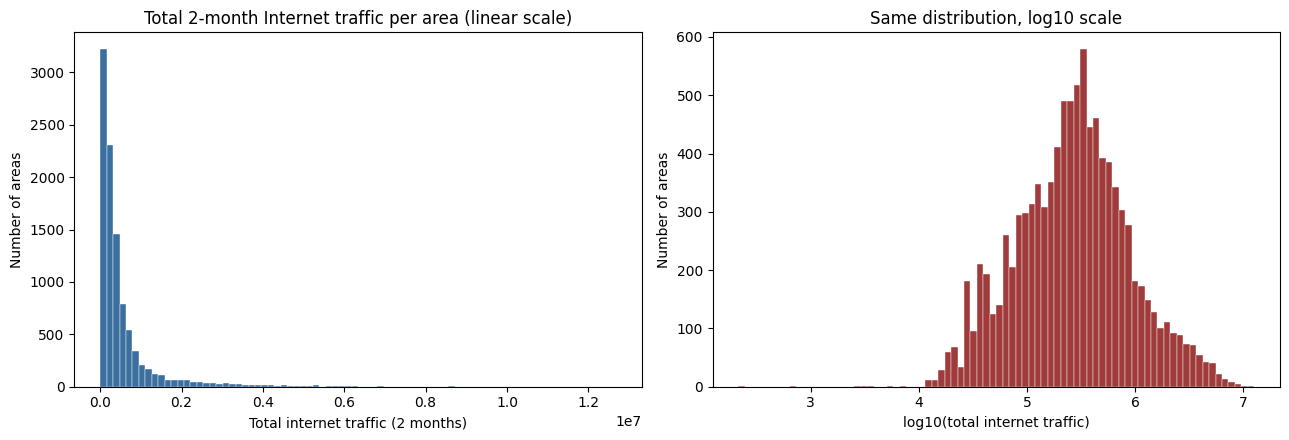

Saved: /content/drive/MyDrive/ML_technique_1/results/distribution_summary.json
{
  "count": 10000.0,
  "mean": 549972.8125,
  "std": 886211.9375,
  "min": 213.62652587890625,
  "25%": 116918.63671875,
  "50%": 274706.203125,
  "75%": 571844.15625,
  "max": 12682673.0,
  "skewness": 4.278303146362305,
  "areas_near_zero_traffic": 0
}


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(square_totals.values, bins=80, color="#3b6fa0", edgecolor="white", linewidth=0.3)
axes[0].set_title("Total 2-month Internet traffic per area (linear scale)")
axes[0].set_xlabel("Total internet traffic (2 months)")
axes[0].set_ylabel("Number of areas")

positive = square_totals[square_totals > 0]
axes[1].hist(np.log10(positive.values), bins=80, color="#a03b3b", edgecolor="white", linewidth=0.3)
axes[1].set_title("Same distribution, log10 scale")
axes[1].set_xlabel("log10(total internet traffic)")
axes[1].set_ylabel("Number of areas")

plt.tight_layout()
save_fig(fig, "fig1_traffic_distribution.png")
plt.show()

distribution_summary = square_totals.describe().to_dict()
distribution_summary["skewness"] = float(square_totals.skew())
distribution_summary["areas_near_zero_traffic"] = int((square_totals < 1).sum())
save_json(distribution_summary, "distribution_summary.json")
print(json.dumps(distribution_summary, indent=2))

### 5.2 Highest-traffic areas and two-week time series comparison

Three highest-traffic areas (2-month total):
5161    12682673.0
5059    11091869.0
5259    10436792.0
Name: internet_total, dtype: float32
Saved: /content/drive/MyDrive/ML_technique_1/figures/fig2_two_week_series.png


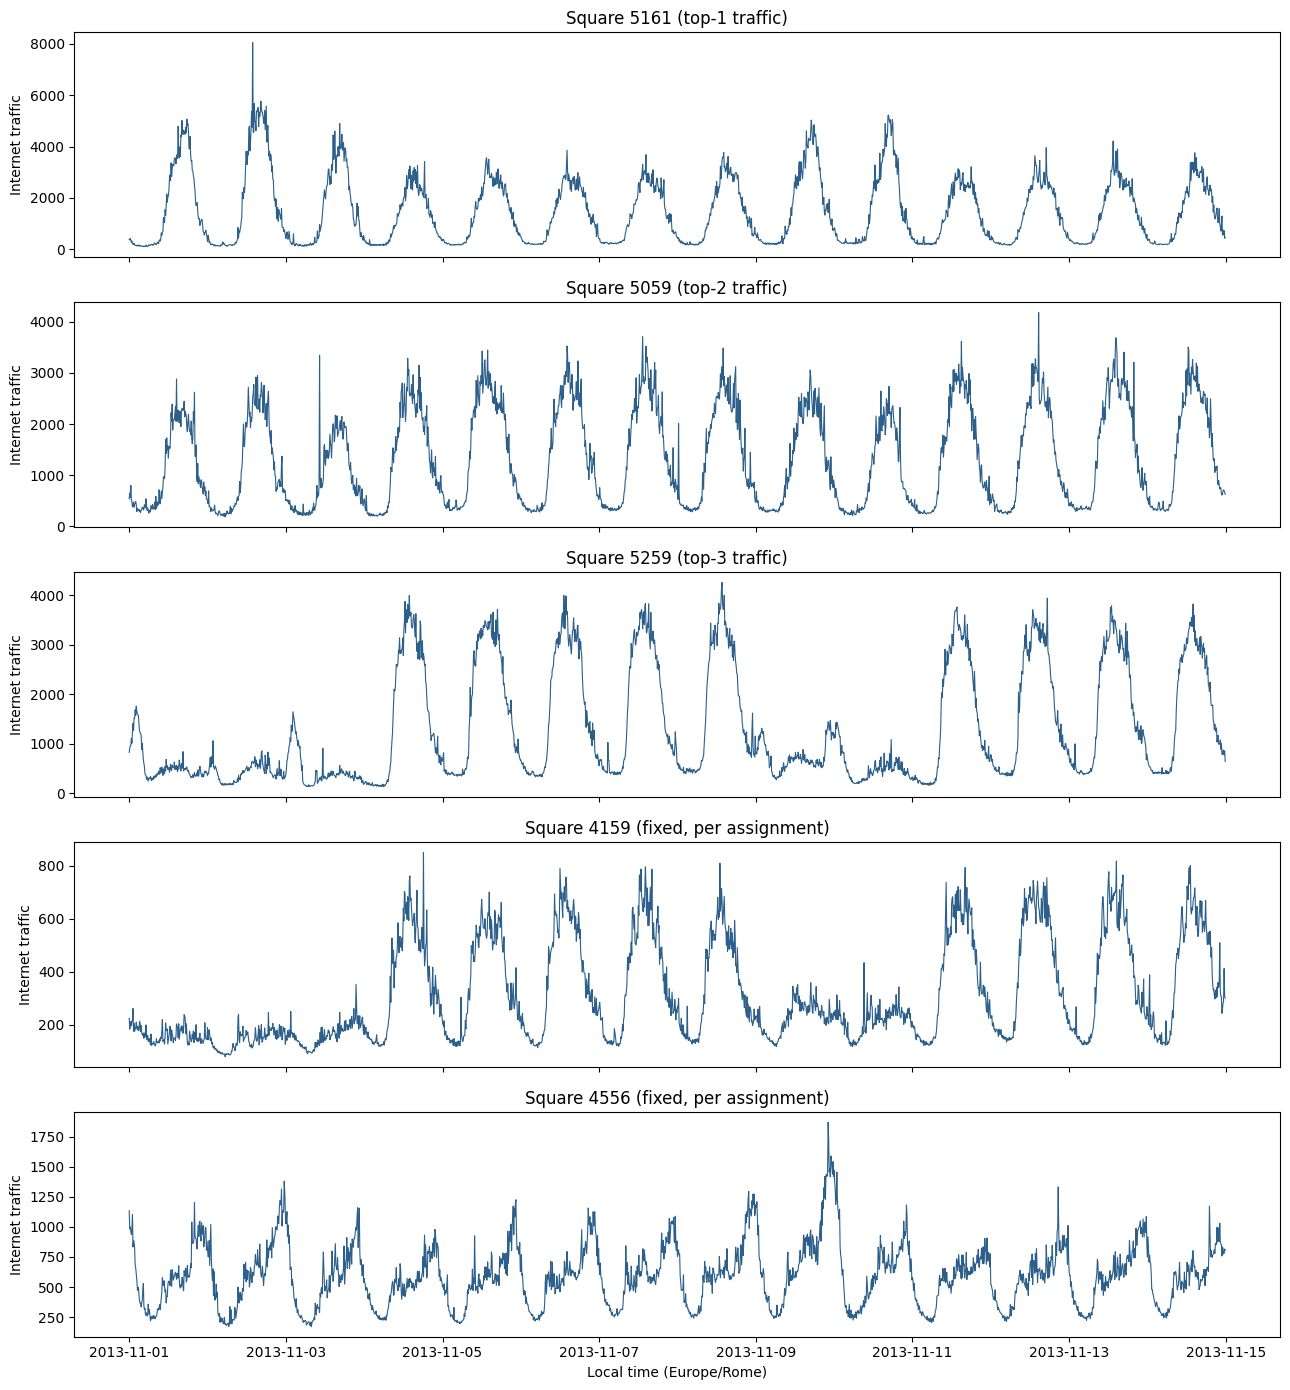

In [ ]:
print("Three highest-traffic areas (2-month total):")
print(square_totals.loc[top3_ids].sort_values(ascending=False))

first_two_weeks = area_wide.loc[area_wide.index < area_wide.index.min() + pd.Timedelta(days=14)]

fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
plot_order = top3_ids + FIXED_SQUARES
labels = [f"Square {sid} (top-{i+1} traffic)" for i, sid in enumerate(top3_ids)] + \
         [f"Square {sid} (fixed, per assignment)" for sid in FIXED_SQUARES]
for ax, sid, label in zip(axes, plot_order, labels):
    ax.plot(first_two_weeks.index, first_two_weeks[sid], linewidth=0.8, color="#2c5f8a")
    ax.set_title(label)
    ax.set_ylabel("Internet traffic")
axes[-1].set_xlabel("Local time (Europe/Rome)")
plt.tight_layout()
save_fig(fig, "fig2_two_week_series.png")
plt.show()

### 5.3 Additional analysis 1 - Autocorrelation (ACF / PACF)

Saved: /content/drive/MyDrive/ML_technique_1/figures/fig3_acf_pacf.png


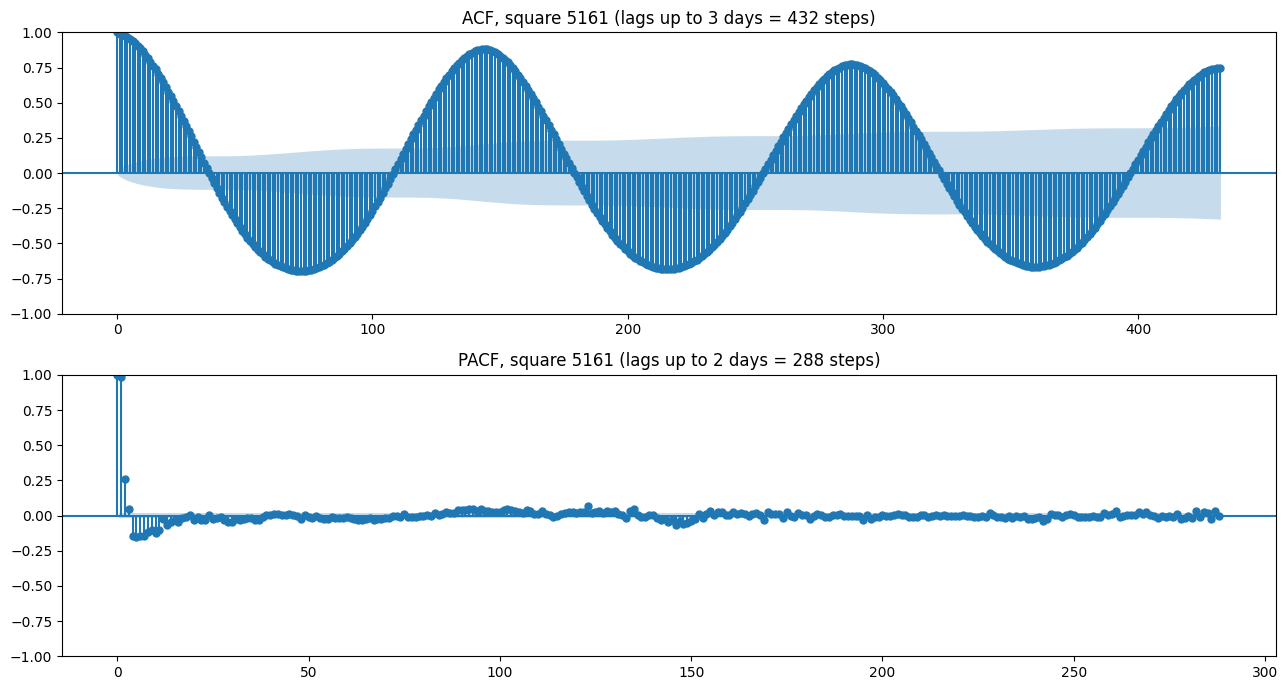

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

top1_id = top3_ids[0]
top1_series = area_wide[top1_id].dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
plot_acf(top1_series, lags=24 * 6 * 3, ax=axes[0])   # up to 3 days of lags
axes[0].set_title(f"ACF, square {top1_id} (lags up to 3 days = 432 steps)")
plot_pacf(top1_series, lags=24 * 6 * 2, ax=axes[1], method="ywm")  # up to 2 days
axes[1].set_title(f"PACF, square {top1_id} (lags up to 2 days = 288 steps)")
plt.tight_layout()
save_fig(fig, "fig3_acf_pacf.png")
plt.show()

### 5.4 Additional analysis 2 - Seasonal decomposition (trend / daily seasonal / residual)

Saved: /content/drive/MyDrive/ML_technique_1/figures/fig4_stl_decomposition.png


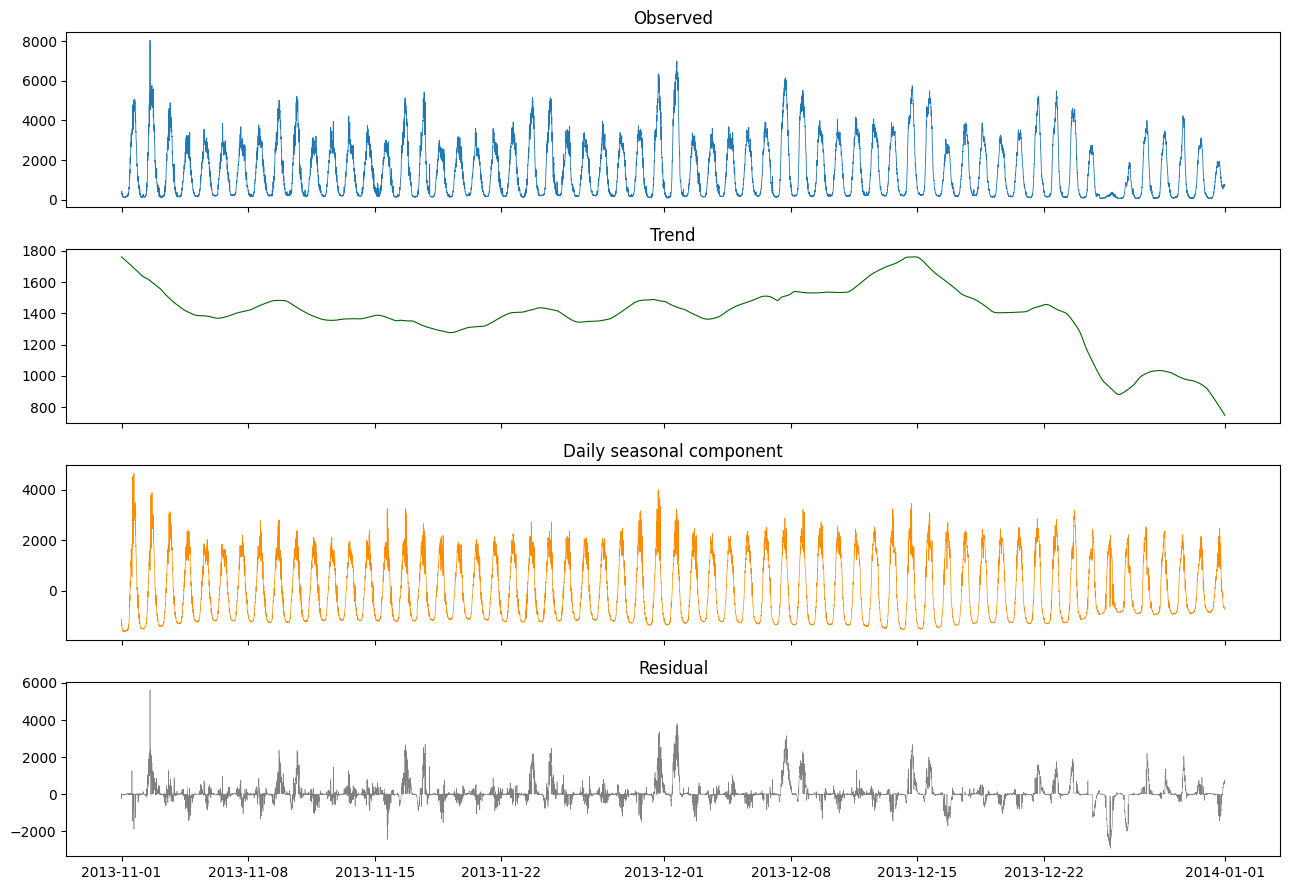

Saved: /content/drive/MyDrive/ML_technique_1/results/stl_summary.json
{
  "area": 5161,
  "seasonal_amplitude": 6274.200059921202,
  "residual_std": 517.1210157994043,
  "amplitude_to_residual_ratio": 12.132943485621205
}


In [ ]:
from statsmodels.tsa.seasonal import STL

stl_input = top1_series.asfreq("10min").interpolate(limit=6).ffill().bfill()
stl = STL(stl_input, period=144, robust=True)
stl_res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(stl_input.index, stl_input.values, linewidth=0.6); axes[0].set_title("Observed")
axes[1].plot(stl_input.index, stl_res.trend, linewidth=0.8, color="darkgreen"); axes[1].set_title("Trend")
axes[2].plot(stl_input.index, stl_res.seasonal, linewidth=0.5, color="darkorange"); axes[2].set_title("Daily seasonal component")
axes[3].plot(stl_input.index, stl_res.resid, linewidth=0.4, color="gray"); axes[3].set_title("Residual")
plt.tight_layout()
save_fig(fig, "fig4_stl_decomposition.png")
plt.show()

resid_std = float(stl_res.resid.std())
seasonal_amp = float(stl_res.seasonal.max() - stl_res.seasonal.min())
stl_summary = {"area": int(top1_id), "seasonal_amplitude": seasonal_amp, "residual_std": resid_std,
               "amplitude_to_residual_ratio": seasonal_amp / resid_std}
save_json(stl_summary, "stl_summary.json")
print(json.dumps(stl_summary, indent=2))

## 6. Forecasting Setup

Task: one-step-ahead $\hat{x}_a(t+1)$ conditioned on the **true** history up to $t$ (not the model's own
past predictions), evaluated as a supervised sliding-window problem rather than recursive multi-step
forecasting. Three models are implemented: (1) seasonal-decomposition + compact ARIMA, (2) LSTM, (3) a
GRU (Gated Recurrent Unit) network - see `Report.md` Section 6-7 for the literature-grounded justification for
this choice, and Section 5.3/5.4 above for the periodicity evidence that sets the window length (L=144,
i.e. 24h) and the seasonal period (144) used below.

### 6.1 Train / validation / test split

In [ ]:
TEST_START  = pd.Timestamp("2013-12-16", tz="Europe/Rome")
TEST_END    = pd.Timestamp("2013-12-23", tz="Europe/Rome")   # exclusive
VAL_START   = pd.Timestamp("2013-12-09", tz="Europe/Rome")
TRAIN_START = area_wide.index.min()

def split_series(s):
    train = s.loc[(s.index >= TRAIN_START) & (s.index < VAL_START)]
    val   = s.loc[(s.index >= VAL_START) & (s.index < TEST_START)]
    test  = s.loc[(s.index >= TEST_START) & (s.index < TEST_END)]
    trainval = s.loc[(s.index >= TRAIN_START) & (s.index < TEST_START)]
    return train, val, test, trainval

tune_area = top3_ids[0]
tune_series = area_wide[tune_area].interpolate(limit=6).ffill().bfill()
tr, va, te, trva = split_series(tune_series)
print(f"Area {tune_area}: train={len(tr)}  val={len(va)}  test={len(te)}  train+val={len(trva)}")

def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat) ** 2)))
def mape(y, yhat, eps=1e-3):
    denom = np.clip(np.abs(y), eps, None)
    return float(np.mean(np.abs((y - yhat) / denom)) * 100)

Area 5161: train=5472  val=1008  test=1008  train+val=6480


### 6.2 Model implementations

In [ ]:
L = 144  # 24h input window (see Section 5.3 ACF analysis)

def make_windows(series_values, L):
    X = np.lib.stride_tricks.sliding_window_view(series_values, L)[:-1].astype("float32")
    y = series_values[L:].astype("float32")
    return X, y

def build_lstm(L, units=32, n_layers=1, lr=1e-3):
    model = keras.Sequential([layers.Input(shape=(L, 1))])
    for i in range(n_layers):
        model.add(layers.LSTM(units, return_sequences=(i < n_layers - 1)))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model

def build_gru(L, units=32, n_layers=1, lr=1e-3):
    model = keras.Sequential([layers.Input(shape=(L, 1))])
    for i in range(n_layers):
        model.add(layers.GRU(units, return_sequences=(i < n_layers - 1)))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model

def fit_deseasonalized_arima(train_values, order):
    n = len(train_values)
    tod = np.arange(n) % 144
    profile = pd.Series(train_values, index=tod).groupby(level=0).mean().values  # length-144 diurnal profile
    deseason = train_values - profile[tod]
    res = sm.tsa.arima.ARIMA(deseason, order=order).fit()
    return profile, res

def arima_one_step_predictions(profile, fitted_res, train_len, new_values):
    n_new = len(new_values)
    tod_new = np.arange(train_len, train_len + n_new) % 144
    deseason_new = new_values - profile[tod_new]
    res_ext = fitted_res.append(deseason_new, refit=False)
    pred_deseason = res_ext.get_prediction(start=train_len, end=train_len + n_new - 1).predicted_mean
    return np.asarray(pred_deseason) + profile[tod_new]

### 6.3 Hyperparameter tuning (grid search, logged iterations)

Tuned once on the highest-traffic area (`tune_area`), scored on the validation week after fitting on
the training period; the selected configuration is reused for all three areas' final models (compute
budget - see `Report.md` Section 6 for the justification). Logs are exported to `results/*_tuning_log.csv`.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(tr.values.reshape(-1, 1))

def scaled_windows(series_slice, history_before, L, scaler):
    """Build (X, y) windows for `series_slice`. If `history_before` is given, the input window is
    allowed to reach back into it (true past values), so the first predictions in a slice are still
    valid one-step forecasts -- consistent with the 'true history up to t' task definition.
    `history_before=None` means there is no real history before `series_slice` (e.g. the very start
    of the dataset), so windows are built strictly within `series_slice` itself."""
    if history_before is None or len(history_before) == 0:
        full = series_slice.values
    else:
        full = np.concatenate([history_before.values[-L:], series_slice.values])
    scaled = scaler.transform(full.reshape(-1, 1)).ravel()
    X, y = make_windows(scaled, L)
    return X[..., None], y

Xtr, ytr = scaled_windows(tr, None, L, scaler)  # train windows: no real history before dataset start
Xva, yva = scaled_windows(va, tr, L, scaler)    # val windows may look back into train history
Xte, yte = scaled_windows(te, trva, L, scaler)  # test windows may look back into train+val history

print("Train windows:", Xtr.shape, "Val windows:", Xva.shape, "Test windows:", Xte.shape)

Train windows: (5328, 144, 1) Val windows: (1008, 144, 1) Test windows: (1008, 144, 1)


In [ ]:
lstm_grid = [
    {"units": 32, "n_layers": 1, "lr": 1e-3},
    {"units": 64, "n_layers": 1, "lr": 1e-3},
    {"units": 64, "n_layers": 2, "lr": 1e-3},
    {"units": 64, "n_layers": 1, "lr": 5e-4},
]

lstm_log = []
for cfg in lstm_grid:
    tf.random.set_seed(42)
    m = build_lstm(L, **cfg)
    es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=20, batch_size=128, callbacks=[es], verbose=0)
    val_pred_scaled = m.predict(Xva, verbose=0).ravel()
    val_pred = scaler.inverse_transform(val_pred_scaled.reshape(-1, 1)).ravel()
    val_true = scaler.inverse_transform(yva.reshape(-1, 1)).ravel()
    lstm_log.append({**cfg, "epochs_ran": len(h.history["loss"]),
                      "val_MAE": mae(val_true, val_pred), "val_RMSE": rmse(val_true, val_pred)})

lstm_log_df = pd.DataFrame(lstm_log)
lstm_log_df.to_csv(os.path.join(RESULTS_DIR, "lstm_tuning_log.csv"), index=False)
print(lstm_log_df)
best_lstm_cfg = lstm_log_df.sort_values("val_MAE").iloc[0].to_dict()
best_lstm_cfg = {"units": int(best_lstm_cfg["units"]), "n_layers": int(best_lstm_cfg["n_layers"]), "lr": best_lstm_cfg["lr"]}
print("Selected LSTM config:", best_lstm_cfg)

   units  n_layers      lr  epochs_ran     val_MAE    val_RMSE
0     32         1  0.0010          20  128.540756  181.758270
1     64         1  0.0010          20  136.362869  189.755676
2     64         2  0.0010          20  130.908920  187.144058
3     64         1  0.0005          20  134.260925  190.019592
Selected LSTM config: {'units': 32, 'n_layers': 1, 'lr': 0.001}


In [ ]:
gru_grid = [
    {"units": 32, "n_layers": 1, "lr": 1e-3},
    {"units": 64, "n_layers": 1, "lr": 1e-3},
    {"units": 64, "n_layers": 2, "lr": 1e-3},
    {"units": 64, "n_layers": 1, "lr": 5e-4},
]

gru_log = []
for cfg in gru_grid:
    tf.random.set_seed(42)
    m = build_gru(L, **cfg)
    es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=20, batch_size=128, callbacks=[es], verbose=0)
    val_pred_scaled = m.predict(Xva, verbose=0).ravel()
    val_pred = scaler.inverse_transform(val_pred_scaled.reshape(-1, 1)).ravel()
    val_true = scaler.inverse_transform(yva.reshape(-1, 1)).ravel()
    gru_log.append({**cfg, "epochs_ran": len(h.history["loss"]),
                     "val_MAE": mae(val_true, val_pred), "val_RMSE": rmse(val_true, val_pred)})

gru_log_df = pd.DataFrame(gru_log)
gru_log_df.to_csv(os.path.join(RESULTS_DIR, "gru_tuning_log.csv"), index=False)
print(gru_log_df)
best_gru_cfg = gru_log_df.sort_values("val_MAE").iloc[0].to_dict()
best_gru_cfg = {"units": int(best_gru_cfg["units"]), "n_layers": int(best_gru_cfg["n_layers"]), "lr": best_gru_cfg["lr"]}
print("Selected GRU config:", best_gru_cfg)

In [ ]:
arima_grid = [(1, 0, 0), (2, 0, 1), (1, 1, 1), (2, 1, 2)]

arima_log = []
train_vals = tr.values
val_vals = va.values
for order in arima_grid:
    t0 = time.time()
    try:
        profile, res = fit_deseasonalized_arima(train_vals, order)
        pred = arima_one_step_predictions(profile, res, len(train_vals), val_vals)
        arima_log.append({"order": str(order), "fit_time_s": time.time() - t0,
                           "val_MAE": mae(val_vals, pred), "val_RMSE": rmse(val_vals, pred), "AIC": res.aic})
    except Exception as e:
        arima_log.append({"order": str(order), "fit_time_s": time.time() - t0, "val_MAE": np.nan, "val_RMSE": np.nan, "AIC": np.nan, "error": str(e)})

arima_log_df = pd.DataFrame(arima_log)
arima_log_df.to_csv(os.path.join(RESULTS_DIR, "arima_tuning_log.csv"), index=False)
print(arima_log_df)
best_arima_order = eval(arima_log_df.sort_values("val_MAE").iloc[0]["order"])
print("Selected ARIMA order:", best_arima_order)

save_json({"L": L, "best_lstm_cfg": best_lstm_cfg, "best_gru_cfg": best_gru_cfg,
           "best_arima_order": list(best_arima_order)}, "selected_hyperparameters.json")

## 7. Final Models, Evaluation, and Comparison

Refits each model's selected configuration **independently per area** on Train+Validation (1 Nov - 15
Dec), evaluates one-step-ahead forecasts on the test week (16-22 Dec), and records training/inference
time. Hardware details captured once for the timing methodology note in the report.

In [ ]:
def cpu_gpu_info():
    info = {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "tensorflow": tf.__version__,
        "gpu_devices": [d.name for d in tf.config.list_physical_devices("GPU")],
    }
    try:
        info["cpu"] = platform.processor() or platform.machine()
    except Exception:
        info["cpu"] = "unknown"
    return info

hardware_info = cpu_gpu_info()
save_json(hardware_info, "hardware_info.json")
print(json.dumps(hardware_info, indent=2))

Saved: /content/drive/MyDrive/ML_technique_1/results/hardware_info.json
{
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "tensorflow": "2.20.0",
  "gpu_devices": [
    "/physical_device:GPU:0"
  ],
  "cpu": "x86_64"
}


In [ ]:
results_rows = []
prediction_store = {}   # (area, model_name) -> (test_index, y_true, y_pred)
timing_rows = []

for area_id in top3_ids:
    series = area_wide[area_id].interpolate(limit=6).ffill().bfill()
    train_v, val_v, test_v, trainval_v = split_series(series)

    area_scaler = MinMaxScaler().fit(trainval_v.values.reshape(-1, 1))
    Xtv, ytv = scaled_windows(trainval_v, None, L, area_scaler)
    Xte_a, yte_a = scaled_windows(test_v, trainval_v, L, area_scaler)
    test_index = test_v.index

    # --- Model 1: Decomposition + ARIMA ---
    t0 = time.time()
    profile, arima_res = fit_deseasonalized_arima(trainval_v.values, tuple(int(x) for x in best_arima_order))
    t_train_arima = time.time() - t0
    t0 = time.time()
    arima_pred = arima_one_step_predictions(profile, arima_res, len(trainval_v.values), test_v.values)
    t_infer_arima = time.time() - t0
    prediction_store[(area_id, "ARIMA+Decomp")] = (test_index, test_v.values, arima_pred)
    timing_rows.append({"area": area_id, "model": "ARIMA+Decomp", "train_time_s": t_train_arima, "inference_time_s": t_infer_arima})

    # --- Model 2: LSTM ---
    tf.random.set_seed(42)
    lstm_model = build_lstm(L, **best_lstm_cfg)
    es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="loss")
    t0 = time.time()
    lstm_model.fit(Xtv, ytv, epochs=20, batch_size=128, callbacks=[es], verbose=0)
    t_train_lstm = time.time() - t0
    t0 = time.time()
    lstm_pred_scaled = lstm_model.predict(Xte_a, verbose=0).ravel()
    t_infer_lstm = time.time() - t0
    lstm_pred = area_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).ravel()
    prediction_store[(area_id, "LSTM")] = (test_index, test_v.values, lstm_pred)
    timing_rows.append({"area": area_id, "model": "LSTM", "train_time_s": t_train_lstm, "inference_time_s": t_infer_lstm})

    # --- Model 3: GRU ---
    tf.random.set_seed(42)
    gru_model = build_gru(L, **best_gru_cfg)
    es2 = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="loss")
    t0 = time.time()
    gru_model.fit(Xtv, ytv, epochs=20, batch_size=128, callbacks=[es2], verbose=0)
    t_train_gru = time.time() - t0
    t0 = time.time()
    gru_pred_scaled = gru_model.predict(Xte_a, verbose=0).ravel()
    t_infer_gru = time.time() - t0
    gru_pred = area_scaler.inverse_transform(gru_pred_scaled.reshape(-1, 1)).ravel()
    prediction_store[(area_id, "GRU")] = (test_index, test_v.values, gru_pred)
    timing_rows.append({"area": area_id, "model": "GRU", "train_time_s": t_train_gru, "inference_time_s": t_infer_gru})

    for model_name in ["ARIMA+Decomp", "LSTM", "GRU"]:
        _, y_true, y_pred = prediction_store[(area_id, model_name)]
        results_rows.append({"area": area_id, "model": model_name,
                              "MAE": mae(y_true, y_pred), "MAPE_%": mape(y_true, y_pred), "RMSE": rmse(y_true, y_pred)})

    print(f"Area {area_id} done.")

results_df = pd.DataFrame(results_rows)
timing_df = pd.DataFrame(timing_rows)
results_df.to_csv(os.path.join(RESULTS_DIR, "results_table.csv"), index=False)
timing_df.to_csv(os.path.join(RESULTS_DIR, "timing_table.csv"), index=False)

### 7.1 Performance tables (MAE / MAPE / RMSE), one per area

In [ ]:
for area_id in top3_ids:
    print(f"--- Area {area_id} ---")
    display(results_df[results_df["area"] == area_id].drop(columns="area").set_index("model").round(4))

### 7.2 Training / inference time

In [ ]:
display(timing_df.round(4))
print()
print("Average training time by model (seconds, across the 3 areas):")
print(timing_df.groupby("model")["train_time_s"].mean().round(3))

### 7.3 Actual vs. predicted traffic - 9 plots (3 areas x 3 models)

In [ ]:
model_names = ["ARIMA+Decomp", "LSTM", "GRU"]
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex="col")
for row, area_id in enumerate(top3_ids):
    for col, model_name in enumerate(model_names):
        ax = axes[row, col]
        idx, y_true, y_pred = prediction_store[(area_id, model_name)]
        ax.plot(idx, y_true, label="Actual", linewidth=0.9, color="black")
        ax.plot(idx, y_pred, label="Predicted", linewidth=0.9, color="crimson", alpha=0.8)
        ax.set_title(f"Area {area_id} - {model_name}")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
        if row == 2:
            ax.set_xlabel("16-22 Dec 2013 (local time)")
plt.tight_layout()
save_fig(fig, "fig5_predictions_grid.png")
plt.show()

### 7.4 Worst-performing window for the best model (failure-case evidence)

In [ ]:
# Identify the largest-error window for the best-performing model (by average test MAE) on the
# highest-traffic area, as a concrete failure case for the report's discussion.
avg_by_model = results_df.groupby("model")["MAE"].mean().sort_values()
best_model_name = avg_by_model.index[0]
print("Best model overall (lowest avg MAE):", best_model_name)

focus_area = top3_ids[0]
idx, y_true, y_pred = prediction_store[(focus_area, best_model_name)]
abs_err = np.abs(y_true - y_pred)
err_series = pd.Series(abs_err, index=idx)

window = 18  # 3 hours
rolling_err = err_series.rolling(window).mean()
worst_center = rolling_err.idxmax()
worst_start, worst_end = worst_center - pd.Timedelta(hours=3), worst_center + pd.Timedelta(hours=3)

fig, ax = plt.subplots(figsize=(12, 4))
mask = (idx >= worst_start) & (idx <= worst_end)
ax.plot(idx[mask], y_true[mask], label="Actual", color="black")
ax.plot(idx[mask], y_pred[mask], label="Predicted", color="crimson")
ax.set_title(f"Worst ~6h window for {best_model_name} on area {focus_area}: {worst_start} to {worst_end}")
ax.legend()
plt.tight_layout()
save_fig(fig, "fig6_worst_window.png")
plt.show()

worst_window_info = {"best_model_name": best_model_name, "focus_area": int(focus_area),
                      "window_start": str(worst_start), "window_end": str(worst_end),
                      "peak_rolling_mae": float(rolling_err.max())}
save_json(worst_window_info, "worst_window_info.json")
print(json.dumps(worst_window_info, indent=2))

## 8. Outputs Summary

All figures are in `./figures/`, all numeric results in `./results/`. Download both folders (or sync the
Drive-mounted cache) and use them to write/finalize `Report.md` - see that document for the full
narrative: introduction, related work, methodology justification, results discussion, conclusion, and
references.

In [ ]:
print("Figures generated:")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(" -", f)
print()
print("Result files generated:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(" -", f)